Plot SOLPS balance file

In [2]:
##### %matplotlib widget


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys, pathlib, shlex, subprocess
# import xbout
import scipy
import netCDF4 

import xhermes
# from xhermes import *
sys.path.append(r"/Users/zero/workspace/phd_work/hms_output/sdtools/")
sys.path.append(r"/Users/zero/workspace/phd_work/hms_output/hermes3-2dplots/pltool")
from code_comparison.solps_pp import *
from hermes3.case_db import *
from hermes3.load import *
from hermes3.named_selections import *
from hermes3.plotting import *
from hermes3.grid_fields import *
from hermes3.accessors import *
from hermes3.utils import *

from common import setup_matplotlib, adapt_solps_conventions

%load_ext autoreload
%autoreload 2
print("Loaded")


Loaded


#### Check variables by reading netcdf

In [3]:
## Checkv variables by netcdf
filepath = "./balance.nc"
nc = netCDF4.Dataset(filepath)
list(nc.variables.keys() )
# key = "pr"
# if key in nc.variables.keys():
#     print(key)
#     print(nc[key])
# else:
#     print("Not found")
# import xarray as xr


# import netCDF4

# filepath = "./balance.nc"
# nc = netCDF4.Dataset(filepath)

# for var_name in nc.variables:
#     var = nc.variables[var_name]
#     # 'long_name' is the standard NetCDF attribute for descriptions
#     description = getattr(var, 'long_name', 'No description available')
#     units = getattr(var, 'units', 'no units')
    
#     print(f"Variable: {var_name}")
#     print(f"  Description: {description}")
#     print(f"  Units: {units}\n")


FileNotFoundError: [Errno 2] No such file or directory: './balance.nc'

## Read SOLPS by solps_pp and read hermes-3

In [20]:
# Read SOLPS
bal = SOLPScase("../ref_puff1e21_radbc0_mirrorsides_atoms_recyct0p99_nofluxlim_novis_nocorrcore_corebccon8_ionisingcore_lluciani0")
bal = adapt_solps_conventions(bal)
# print(type(bal))

# Read Hermes-3
db = CaseDB(
    case_dir = r"/Users/zero/workspace/phd_work/hms_output/",
    grid_dir = r"/Users/zero/workspace/phd_work/hms_output/gridfile"
    # grid_dir = r"/users/jpm590/neutralrun/hermes-3/master"

)
toload = [
    dict(name="260717_highrsl_6e20_coreOO", id="260717_highrsl_6e20_coreOO", unnormalise_geom = True, use_xhermes = True, squash = True),   
    dict(name="260706_highrsl_1e21_corebc_OO", id="260706_highrsl_1e21_corebc_OO", unnormalise_geom = True, use_xhermes = True, squash = True),   
    # dict(name="nowallpump_1e21", id="260427_reproduce_1e21_neumann_nowallpump", unnormalise_geom = True, use_xhermes = True, squash = True),

]
cs = {}
for case in toload:
    cs[case["name"]] = db.load_case_2D(case["id"], use_squash = case["squash"], verbose = True)

    cs[case["name"]].extract_2d_tokamak_geometry()

/Users/zero/workspace/phd_work/hms_output/xhermes/lib/python3.12/site-packages/boutdata/data.py:762: AlwaysWarning: While building x, y, z coordinate arrays, an exception occured: [Errno 2] No such file or directory: '"CDN_46895_260513_nowallpump_6e20.nc"'
Evaluating non-scalar options not available
  alwayswarn(


- Reading case 260717_highrsl_6e20_coreOO
-----------------------
- Looking for squash file
- Squash file found. squash date 07/22/2026, 21:42:01, dmp file date 07/22/2026, 21:08:16


/Users/zero/workspace/phd_work/hms_output/xhermes/lib/python3.12/site-packages/boutdata/data.py:762: AlwaysWarning: While building x, y, z coordinate arrays, an exception occured: 'PosixPath' object has no attribute 'split'
Evaluating non-scalar options not available
  alwayswarn(
/Users/zero/workspace/phd_work/hms_output/xBOUT/xbout/load.py:1294: UserWarning: Will drop all variables containing the dimensions 'closed_wall' because they are not recognised
  warn(



Unnormalising with xHermes
- Reading case 260706_highrsl_1e21_corebc_OO
-----------------------
- Looking for squash file
- Squash file found. squash date 07/17/2026, 12:32:08, dmp file date 07/17/2026, 08:25:51


/Users/zero/workspace/phd_work/hms_output/xhermes/lib/python3.12/site-packages/boutdata/data.py:762: AlwaysWarning: While building x, y, z coordinate arrays, an exception occured: [Errno 2] No such file or directory: '"CDN_46895_260427_nowallpump_1e21.nc"'
Evaluating non-scalar options not available
  alwayswarn(
/Users/zero/workspace/phd_work/hms_output/xhermes/lib/python3.12/site-packages/boutdata/data.py:762: AlwaysWarning: While building x, y, z coordinate arrays, an exception occured: 'PosixPath' object has no attribute 'split'
Evaluating non-scalar options not available
  alwayswarn(
/Users/zero/workspace/phd_work/hms_output/xBOUT/xbout/load.py:1294: UserWarning: Will drop all variables containing the dimensions 'closed_wall' because they are not recognised
  warn(



Unnormalising with xHermes


In [21]:
df = bal.get_1d_radial_data(params=["Td+","Nd+","Te","Ne",], region="omp")

ds = cs["260717_highrsl_6e20_coreOO"].ds.isel(t=-1)
ds = cs["260706_highrsl_1e21_corebc_OO"].ds.isel(t=-1)

## Check some number between the two

In [ ]:


# Hermes-3 
print("\n" + "="*50)
print("Hermes-3 Parameters")
print("="*50)

ds = cs["260717_highrsl_6e20_coreOO"].ds.isel(t=-1)

nparticle = (ds["Nd+"].values +
             ds["Nd"].values +
             ds["Ne"].values) * ds["dv"].values
nparticles = np.sum(nparticle)
nion= (ds["Nd+"].values  * ds["dv"].values)
nions = np.sum(nion)
ne= (ds["Ne"].values  * ds["dv"].values)
nes = np.sum(ne)

puff_rate = np.sum(ds["Sd_src"].values * ds["dv"].values)

extra_particles = nparticles - puff_rate

recycled_neutral = np.sum(
    ds["Sd_target_recycle"].values * ds["dv"].values
)
# print(ds["Sd_target_recycle"].values)
recomb = np.sum(
    ds["Sd+_rec"].values * ds["dv"].values
)
iz = np.sum(
    ds["Sd+_iz"].values * ds["dv"].values
)
ext_ion_src = np.sum(
    ds["Sd+_src"].values * ds["dv"].values
)

print(f"{'Total particles:':30s} {nparticles:15.6e}")
print(f"{'Total ions:':30s} {nions:15.6e}")
print(f"{'Total electrons:':30s} {nes:15.6e}")

print(f"{'Puff rate (Sd_src):':30s} {puff_rate:15.6e}")
print(f"{'Extra particles:':30s} {extra_particles:15.6e}")
print("-"*50)
print(f"{'Expected ion lost (1%):':30s} {puff_rate*0.01:15.6e}")
print(f"{'Expected n recycled (99%):':30s} {puff_rate*0.99:15.6e}")
print(f"{'Actual recycled neutrals:':30s} {recycled_neutral:15.6e}")
print("-"*50)
print("Total sink of ions")
#original ion flux into target recycled_neutral/0.99
lost_ion = recycled_neutral/0.99*0.01
print(f"{'Sd+_rec:':30s} {recomb:15.6e}")
print(f"{'ion lost:':30s} {lost_ion:15.6e}")

print("Total source of ions")
print(f"{'Sd+_iz:':30s} {iz:15.6e}")

# print(f"external ions {'Sd+_src':30s} {ext_ion_src:15.6e}")


print("="*50)


## Plot variables in 1D

In [ ]:


fig, ax = plt.subplots(1,3, figsize=(8,3))
ax[0].plot(df["dist"], df["Td+"])
ax[0].set_title("SOLPS")

## Hermes-3
ds = cs["260717_highrsl_6e20_coreOO"].ds.isel(t=-1)


df_hermes = get_1d_radial_data(ds, params = ["Td+"], region = "omp")
ax[1].plot(df_hermes["Srad"], df_hermes["Td+"])
ax[1].set_title("Hermes-3")

ax[2].plot(df["dist"], df["Td+"])
ax[2].plot(df_hermes["Srad"], df_hermes["Td+"])
ax[2].set_title("SOLPS vs Hermes-3")



## Plot 2D polygon

In [ ]:
# Plot separatrix of SOLPS
fig, ax = plt.subplots()
bal.plot_separatrix(ax=ax, ls = "-", c="red")
ax.set_aspect('equal', adjustable='box')


In [ ]:
fig, ax = plt.subplots()

bal.plot_2d(ax=ax, param="Te")

ax.set_aspect('equal', adjustable='box')


# Fort.44 variables
(Below are things done in UKAEA visiting to check the neutral flux)

`pfluxa`: pfluxa Poloidal flux density of atoms

`pfluxa_padded` is a pfluxa reshape and filling zero into guard cell to match `plot_2d` function

In [ ]:
# Extract pfluxa from fort.44 and pad to (nx, ny)
import numpy as np
import builtins

filename = "../ref_puff1e21_radbc0_mirrorsides_atoms_recyct0p99_nofluxlim_novis_nocorrcore_corebccon8_ionisingcore_lluciani0/fort.44"
var_name = "pfluxa"
with builtins.open(filename, 'r') as f:
    lines = f.readlines()

data_lines = []
found = False
for line in lines:
    if line.startswith(f"*eirene data field {var_name}"):
        found = True
        continue
    if found:
        if line.startswith("*"):
            break
        data_lines.append(line)

data = []
for line in data_lines:
    data.extend([float(x) for x in line.split()])

pfluxa = np.array(data)
print(f"Raw pfluxa (an array): {pfluxa}")

# Number of cells in balance.nc
nx, ny = bal.g["nx"], bal.g["ny"]
print(f"pfluxa size = {pfluxa.size}, nx = {nx}, ny = {ny}, nx*ny = {nx*ny}")
# print(f"Shape of pfluxa from fort.44: {np.shape(pfluxa)}")

# fort.44 outputs without guard cells: shape is (nx-2, ny-2)
# Fortran order ('F') means first dimension (poloidal) varies fastest.
pfluxa_inner = pfluxa.reshape((nx-2, ny-2), order='F')
# print(f"pfluxa_inner: {pfluxa_inner}")


# Pad with zeros to match SOLPS grid shape (nx, ny)
pfluxa_padded = np.zeros((nx, ny))
pfluxa_padded[1:-1, 1:-1] = pfluxa_inner
# print(pfluxa_padded)



# Plot using bal's plot_2d
# We need to flatten it since SOLPScase plot_2d expects a flattened array or internal data
try:
    # plot_2d uses the parameter as a title, and data for the values if provided
    bal.plot_2d(var_name, data=pfluxa_padded, logscale=True, cmap="plasma")
except Exception as e:
    print(f"Error plotting: {e}")


In [ ]:

# --- Velocity Calculation ---
# Get Neutral Density from your SOLPScase (shape is already nx, ny)
Nd = bal.bal["Na"]
# Do a safe division: Vd = pfluxa / Nd (outputs 0 where Nd is 0)
Vd = np.divide(pfluxa_padded, Nd, out=np.zeros_like(pfluxa_padded), where=(Nd!=0))
# Plot the new velocity array!
bal.plot_2d("Vd", data=Vd, logscale=True,vmin= - 1e5, vmax=1e5, cmap="plasma")

In [ ]:
### Hermes-3
fig, ax = plt.subplots()
ds = cs["260717_highrsl_6e20"].ds.isel(t=-1)
ds["Vd_pol"]=ds["Vd"]*abs(ds["Bpxy"] / abs(ds["Bxy"]))
ds["Vd_pol"].bout.polygon(ax = ax , cmap = "plasma", antialias = True,logscale = True ,vmin= - 1e5, vmax=1e5,)

In [ ]:
## Polodial neutral velocity 

bal.bal["pfluxa"] = pfluxa_padded
# SOLPS
dsolps = bal.get_1d_poloidal_data(params=["Na","pfluxa"], region="outer_lower_sol", sepadd=1, target_first=True,
                      interpolate_midplane=False, interpolate_radial=False)
dsolps["Vd"]=dsolps["pfluxa"]/dsolps["Na"]
print(dsolps)

# Hermes-3
dhermes = get_1d_poloidal_data(ds, params=["Nd", "Vd","Bpxy","Bxy"], region="outer_lower_sol", sepadd=1, target_first=True,
                      interpolate_midplane=False, interpolate_radial=False)
dhermes["Vd_pol"]=dhermes["Vd"]*abs(dhermes["Bpxy"] / abs(dhermes["Bxy"]))

fig, ax = plt.subplots()
ax.plot(dsolps["Spol"], dsolps["Vd"], label="SOLPS")
ax.plot(dhermes["Spol"], dhermes["Vd_pol"], label="Hermes-3")
ax.legend()
ax.grid(alpha=0.7)
ax.set_yscale("symlog")
plt.show()

In [ ]:
## Parallel neutral velocity

fig, ax = plt.subplots()
ax.plot(dsolps["Spar"], dsolps["Vd"], label="SOLPS")
ax.plot(dhermes["Spar"], dhermes["Vd"], label="Hermes-3")
ax.legend()
ax.grid(alpha=0.7)
ax.set_yscale("symlog")
plt.show()

In [ ]:
fig, ax = plt.subplots()
ds["Vd_pol"]=ds["Vd"]*abs(ds["Bpxy"] / abs(ds["Bxy"]))
ds["Vd_pol"].bout.polygon(ax = ax , cmap = "Spectral_r", antialias = True,logscale = True ,vmin= - 1e5, vmax=1e5)

# Compare between SOLPS files

- SOLPS_limiter_off: electron conduction limiter  

- SOLPS_Luciani_off: electron conduction limiter off and Luciani off


In [14]:
from pltool.common import  adapt_solps_conventions

setup_matplotlib()

# Returns a dict {name: SOLPScase} when more than one id is given
def read_solps_balance(input_id=None):
    """Read one or more SOLPS balance files.

    input_id : str or list of str, keys of SOLPS_CASES. None -> all cases.
    Returns a single SOLPScase for one id, else a dict {name: SOLPScase}.
    """
    root = "/Users/zero/workspace/phd_work/hms_output"

    # SOLPScase init appends "balance.nc", so only the folder is required
    SOLPS_CASES = {
        "1e21":         os.path.join(root, "SOLPS_Luciani_off"),
        "cx100_1e21":         os.path.join(root, "SOLPS_Luciani_off_cx100"),
        "cx100_1e22":         os.path.join(root, "SOLPS_Luciani_off_cx100_1e22"),
    }
    # print(os.path.join(root, "SOLPS_Luciani_off"))
    # print(os.path.join(root, "SOLPS_limiter_off"))
    if input_id is None:
        ids = list(SOLPS_CASES)
    elif isinstance(input_id, str):
        ids = [input_id]
    else:
        ids = list(input_id)

    for i in ids:
        if i not in SOLPS_CASES:
            raise KeyError(f"Unknown SOLPS id '{i}', choose from {list(SOLPS_CASES)}")

    bals = {i: SOLPScase(SOLPS_CASES[i]) for i in ids}

    return bals[ids[0]] if len(ids) == 1 else bals
bals = read_solps_balance(["1e21", "cx100_1e21", "cx100_1e22"])

# adapt_solps_conventions takes a single case, so map it over the dict
bals = {k: adapt_solps_conventions(v) for k, v in bals.items()}

print(list(bals))


['1e21', 'cx100_1e21', 'cx100_1e22']


### Radial comparison

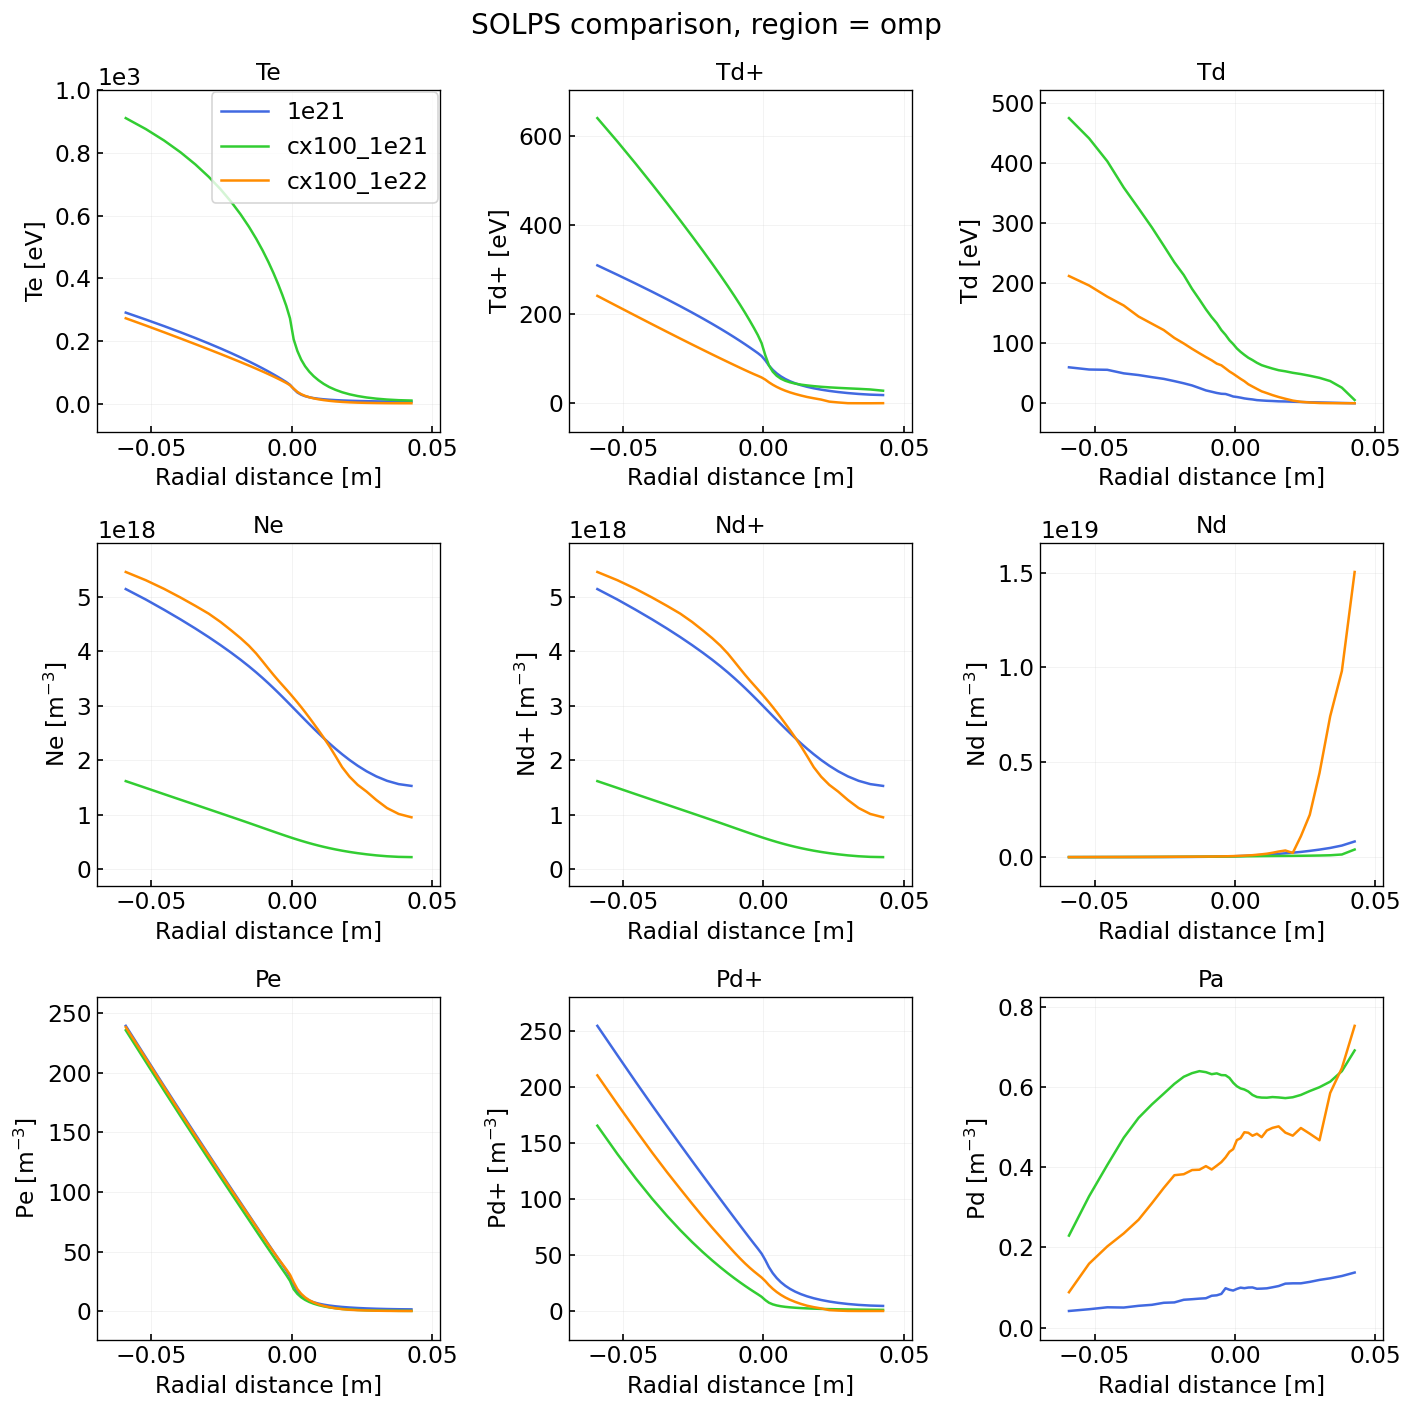

In [13]:
region_rad = "omp"

params_rad = [
    ("Te",  "Te [eV]"),
    ("Td+", "Td+ [eV]"),
    ("Td",  "Td [eV]"),
    ("Ne",  "Ne [m$^{-3}$]"),
    ("Nd+", "Nd+ [m$^{-3}$]"),
    ("Nd",  "Nd [m$^{-3}$]"),
    ("Pe",  "Pe [m$^{-3}$]"),
    ("Pd+", "Pd+ [m$^{-3}$]"),
    ("Pa",  "Pd [m$^{-3}$]"),
]

cols = 3
rows = int(np.ceil(len(params_rad) / cols))          # np already imported; no math needed
fig, ax = plt.subplots(rows, cols, figsize=(12, 4 * rows), squeeze=False)
axs = ax.flatten()                                    # 1-D list of axes to zip over

# one line per SOLPS case, one subplot per variable
for name, b in bals.items():
    df = b.get_1d_radial_data(params=[p for p, _ in params_rad], region=region_rad)
    for axi, (p, _) in zip(axs, params_rad):
        axi.plot(df["dist"], np.abs(df[p]), label=name)

# format each used panel
for axi, (p, ylabel) in zip(axs, params_rad):
    axi.set_xlabel("Radial distance [m]")
    axi.set_ylabel(ylabel)
    axi.set_title(p)
    axi.grid(alpha=0.3)

# hide any leftover empty panels
for axi in axs[len(params_rad):]:
    axi.axis("off")

axs[0].legend()
fig.suptitle(f"SOLPS comparison, region = {region_rad}")
fig.tight_layout()


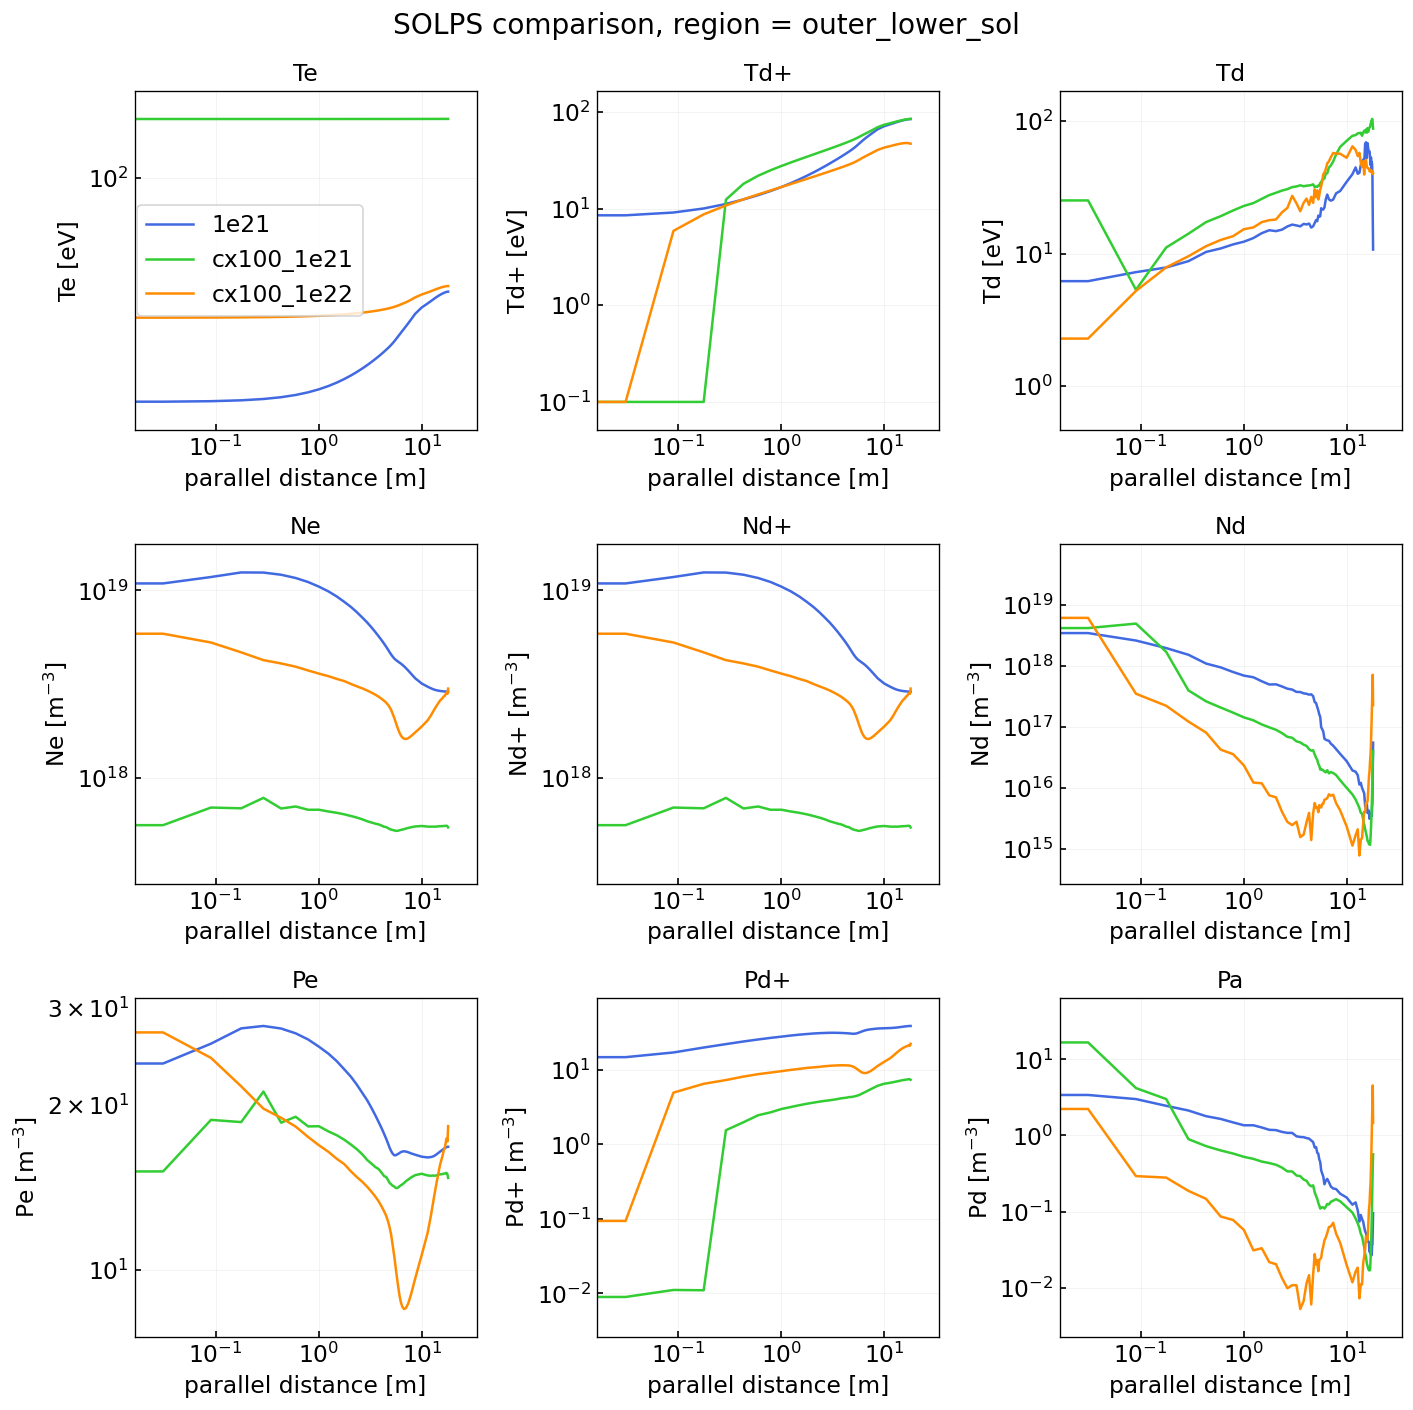

In [12]:
region_parallel = "outer_lower_sol"

params_parallel = [
    ("Te",  "Te [eV]"),
    ("Td+", "Td+ [eV]"),
    ("Td",  "Td [eV]"),
    ("Ne",  "Ne [m$^{-3}$]"),
    ("Nd+", "Nd+ [m$^{-3}$]"),
    ("Nd",  "Nd [m$^{-3}$]"),
    ("Pe",  "Pe [m$^{-3}$]"),
    ("Pd+", "Pd+ [m$^{-3}$]"),
    ("Pa",  "Pd [m$^{-3}$]"),
]

cols = 3
rows = int(np.ceil(len(params_parallel) / cols))          # np already imported; no math needed
fig, ax = plt.subplots(rows, cols, figsize=(12, 4 * rows), squeeze=False)
axs = ax.flatten()                                    # 1-D list of axes to zip over

# one line per SOLPS case, one subplot per variable
for name, b in bals.items():
    df = b.get_1d_poloidal_data(params=[p for p, _ in params_parallel], sepadd=1, region=region_parallel,target_first=True, interpolate_midplane=False, interpolate_radial=False )
    for axi, (p, _) in zip(axs, params_parallel):
        axi.plot(df["Spar"], np.abs(df[p]), label=name)

# format each used panel
for axi, (p, ylabel) in zip(axs, params_parallel):
    axi.set_xlabel("parallel distance [m]")
    axi.set_ylabel(ylabel)
    axi.set_title(p)
    axi.grid(alpha=0.3)
    axi.set_xscale("log")
    axi.set_yscale("log")

# hide any leftover empty panels
for axi in axs[len(params_parallel):]:
    axi.axis("off")

axs[0].legend()
fig.suptitle(f"SOLPS comparison, region = {region_parallel}")
fig.tight_layout()

In [ ]:
region_parallel = "outer_lower_sol"

params_parallel = [
            ("Sd+_rec", "Recombination source [$m^{-3} s^{-1}$]"),
            ("Sd+_iz",  "Ionisation source [$m^{-3} s^{-1}$]"),
            ("Edd+_cx", "Charge exchange energy [$W m^{3}$]"),
]

cols = 3
rows = int(np.ceil(len(params_parallel) / cols))          # np already imported; no math needed
fig, ax = plt.subplots(rows, cols, figsize=(12, 4 * rows), squeeze=False)
axs = ax.flatten()                                    # 1-D list of axes to zip over

# one line per SOLPS case, one subplot per variable
for name, b in bals.items():
    df = b.get_1d_poloidal_data(params=[p for p, _ in params_parallel], sepadd=1, region=region_parallel,target_first=True, interpolate_midplane=False, interpolate_radial=False )
    for axi, (p, _) in zip(axs, params_parallel):
        axi.plot(df["Spar"], np.abs(df[p]), label=name)

# format each used panel
for axi, (p, ylabel) in zip(axs, params_parallel):
    axi.set_xlabel("parallel distance [m]")
    axi.set_ylabel(ylabel)
    axi.set_title(p)
    axi.grid(alpha=0.3)
    axi.set_yscale("symlog")

# hide any leftover empty panels
for axi in axs[len(params_parallel):]:
    axi.axis("off")

axs[0].legend()
fig.suptitle(f"SOLPS comparison, region = {region_parallel}")
fig.tight_layout()

In [ ]:
region_radial = "omp"

params_radial = [
            ("Sd+_rec", "Recombination source [$m^{-3} s^{-1}$]"),
            ("Sd+_iz",  "Ionisation source [$m^{-3} s^{-1}$]"),
            ("Edd+_cx", "Charge exchange energy [$W m^{3}$]"),
]

cols = 3
rows = int(np.ceil(len(params_radial) / cols))          # np already imported; no math needed
fig, ax = plt.subplots(rows, cols, figsize=(12, 4 * rows), squeeze=False)
axs = ax.flatten()                                    # 1-D list of axes to zip over

# one line per SOLPS case, one subplot per variable
for name, b in bals.items():
    df = b.get_1d_radial_data(params=[p for p, _ in params_radial],  region=region_radial )
    for axi, (p, _) in zip(axs, params_radial):
        axi.plot(df["dist"], np.abs(df[p]), label=name)

# format each used panel
for axi, (p, ylabel) in zip(axs, params_radial):
    axi.set_xlabel("radial distance [m]")
    axi.set_ylabel(ylabel)
    axi.set_title(p)
    axi.grid(alpha=0.3)
    axi.set_yscale("symlog")

# hide any leftover empty panels
for axi in axs[len(params_radial):]:
    axi.axis("off")

axs[0].legend()
fig.suptitle(f"SOLPS comparison, region = {region_radial}")
fig.tight_layout()

## Check specific variable


In [ ]:
# SOLPS
bal = SOLPScase("../SOLPS_Luciani_off_cx100")
df = bal.get_1d_radial_data(params=["Td+","Nd+","Te","Ne","Vd+","Ve"], region="omp")
df

In [8]:
def resolve_solps_case(key=None):
    """Return a single SOLPScase from whatever is in the namespace."""
    cand = None
    for name in ("bals", "bal"):
        obj = globals().get(name)
        if obj is None:
            continue
        if isinstance(obj, dict):
            if key is None:
                key = list(obj)[0]
            if key not in obj:
                raise KeyError(f"'{key}' not in {name}: choose from {list(obj)}")
            cand = obj[key]
        else:
            cand = obj
        break
    if cand is None:
        raise NameError("No SOLPS case found - run the load cell to define `bal` or `bals`")

    if "Nd" not in cand.bal:
        cand = adapt_solps_conventions(cand)
    return cand


# Neutral penetration depth: SOLPS (kinetic) vs Hermes-3 (fluid)

Gas is puffed at the OMP, so the question "how deep does the fuelling get?" is set by how
far a neutral travels before it is destroyed (ionisation) or has its velocity randomised
(charge exchange). Compare the two codes through the mean free paths:

| Quantity | Definition | Meaning |
|---|---|---|
| $\nu_{iz}$ | $n_e \langle\sigma v\rangle_{iz}$ | ionisation frequency of a neutral [s$^{-1}$] |
| $\nu_{cx}$ | $n_{d+} \langle\sigma v\rangle_{cx}$ | CX frequency of a neutral [s$^{-1}$] |
| $\lambda_{iz}$ | $v_n / \nu_{iz}$ | ballistic ionisation mfp [m] |
| $\lambda_{cx}$ | $v_n / \nu_{cx}$ | CX mfp [m] |
| $\lambda_{pen}$ | $\sqrt{\lambda_{iz}\lambda_{cx}/3}$ | diffusive penetration depth when $\lambda_{cx}\ll\lambda_{iz}$ |

$v_n = \sqrt{8 e T_d/(\pi m_d)}$ is the neutral mean thermal speed.

**Two independent estimates are computed for each code:**

1. **Analytic** — the AMJUEL fits Hermes-3 itself uses (`H.4 2.1.5` for ionisation,
   `H.2 3.1.8` for CX) evaluated on each code's *own* $n_e, T_e, n_{d+}, T_{d+}, T_d$
   profiles. Identical rate coefficients on both sides, so every difference comes from the
   profiles and from the neutral speed model. This is the apples-to-apples comparison.
2. **Code-native** — rates read straight out of each code's diagnostics:
   $\nu_{iz} = S_{d+,iz}/n_d$ for both, and $\nu_{cx} = K_{dd+,cx}$ for Hermes-3.
   SOLPS `balance.nc` carries no CX particle tally, so SOLPS CX is analytic-only.
   The analytic-vs-native gap is what tells you whether a `rate_multiplier`
   (e.g. the `cx100` cases) or the EIRENE kinetic treatment is doing the work.

**Caveats to keep in mind when reading the plots**

- In EIRENE, `Ta`/`Td` is the *moment* of a strongly non-Maxwellian distribution: it mixes
  cold puffed molecules/Franck-Condon atoms (~2-3 eV) with a hot CX-generated tail. A single
  $v_n = \sqrt{8eT_d/\pi m_d}$ therefore under-represents the fast population that actually
  sets penetration. Hermes-3's $T_d$ is a genuine fluid temperature, so the same formula is
  a fair description there but not in SOLPS.
- SOLPS `Td` here is $T_n = P_n/n_n$ (atoms + molecules, see `adapt_solps_conventions`),
  whereas Hermes-3 `d` is atoms only. The `Nd`/`Na` comparison is atoms-vs-atoms.
- Hermes-3's fluid neutrals are additionally limited by the `Dnn` flux-limiter and by
  `Kd_mfp_pseudo_coll`, which is *not* captured by $\lambda_{iz}$/$\lambda_{cx}$ alone.


In [10]:
# ============================================================================
# AMJUEL rate coefficients - the same fits Hermes-3 evaluates internally.
#   ionisation : H.4 2.1.5  (double poly in ln(T), ln(n/1e14))   -> src/amjuel_data.cxx
#   CX         : H.2 3.1.8  (single poly in ln(Teff))
# Conventions copied from my-hermes-3: eval_amjuel_*_fit + the 1e-6 cm^3->m^3
# conversion applied at the call site in src/reaction.cxx.
# ============================================================================

QE = 1.602176634e-19
MP = 1.67262192369e-27
MD = 2.0 * MP  # deuterium

# H.4 2.1.5 - coeffs[i][j]: i = power of ln(T[eV]), j = power of ln(n/1e14 m^-3)
_AMJUEL_H4_2_1_5 = np.array([
    [-32.4802533034, -0.05440669186583, 0.09048888225109, -0.04054078993576, 0.008976513750477, -0.001060334011186, 6.846238436472e-05, -2.242955329604e-06, 2.890437688072e-08],
    [14.2533239151, -0.0359434716076, -0.02014729121556, 0.0103977361573, -0.001771792153042, 0.0001237467264294, -3.130184159149e-06, -3.051994601527e-08, 1.888148175469e-09],
    [-6.632235026785, 0.09255558353174, -0.005580210154625, -0.005902218748238, 0.001295609806553, -0.0001056721622588, 4.646310029498e-06, -1.479612391848e-07, 2.85225125832e-09],
    [2.059544135448, -0.07562462086943, 0.01519595967433, 0.0005803498098354, -0.0003527285012725, 3.201533740322e-05, -1.835196889733e-06, 9.474014343303e-08, -2.342505583774e-09],
    [-0.442537033141, 0.02882634019199, -0.00728577148505, 0.0004643389885987, 1.145700685235e-06, 8.493662724988e-07, -1.001032516512e-08, -1.476839184318e-08, 6.047700368169e-10],
    [0.06309381861496, -0.00578868653578, 0.00150738295525, -0.0001201550548662, 6.574487543511e-06, -9.678782818849e-07, 5.176265845225e-08, 1.29155167686e-09, -9.685157340473e-11],
    [-0.005620091829261, 0.000632910556804, -0.0001527777697951, 8.270124691336e-06, 3.224101773605e-08, 4.377402649057e-08, -2.622921686955e-09, -2.259663431436e-10, 1.161438990709e-11],
    [0.0002812016578355, -3.564132950345e-05, 7.222726811078e-06, 1.433018694347e-07, -1.097431215601e-07, 7.789031791949e-09, -4.197728680251e-10, 3.032260338723e-11, -8.911076930014e-13],
    [-6.011143453374e-06, 8.089651265488e-07, -1.186212683668e-07, -2.381080756307e-08, 6.271173694534e-09, -5.48301024493e-10, 3.064611702159e-11, -1.355903284487e-12, 2.935080031599e-14],
])

# H.2 3.1.8 - coeffs[k]: k = power of ln(Teff[eV])
_AMJUEL_H2_3_1_8 = np.array([
    -18.5028, 0.3708409, 0.007949876, -0.0006143769, -0.0004698969,
    -0.0004096807, 0.0001440382, -1.514243e-05, 5.122435e-07,
])


def sigmav_iz(Te_eV, ne_m3):
    """Effective hydrogenic ionisation rate coefficient [m^3/s]. AMJUEL H.4 2.1.5."""
    Te = np.clip(np.asarray(Te_eV, dtype=float), 0.1, 1e4)
    ne = np.clip(np.asarray(ne_m3, dtype=float), 1e14, 1e22)
    lnT = np.log(Te)
    lnn = np.log(ne / 1e14)
    i = np.arange(_AMJUEL_H4_2_1_5.shape[0])[:, None, None]
    j = np.arange(_AMJUEL_H4_2_1_5.shape[1])[None, :, None]
    terms = _AMJUEL_H4_2_1_5[:, :, None] * lnT[None, None, :] ** i * lnn[None, None, :] ** j
    return 1e-6 * np.exp(terms.sum(axis=(0, 1)))


def sigmav_cx(Td_eV, Tdplus_eV, AA=2.0):
    """H + H+ -> H+ + H rate coefficient [m^3/s]. AMJUEL H.2 3.1.8.

    Uses Hermes-3's effective temperature Teff = sum_heavy(T_s / AA_s), clamped to
    [0.01, 1e4] eV (see calc_Teff in include/rate_helper.hxx).
    """
    Teff = np.clip(np.asarray(Td_eV, float) / AA + np.asarray(Tdplus_eV, float) / AA, 0.01, 1e4)
    lnT = np.log(Teff)
    k = np.arange(_AMJUEL_H2_3_1_8.size)[:, None]
    return 1e-6 * np.exp((_AMJUEL_H2_3_1_8[:, None] * lnT[None, :] ** k).sum(axis=0))


def neutral_thermal_speed(Td_eV, mass=MD, kind="mean"):
    """Neutral speed [m/s]. kind = 'mean' (8kT/pi m), 'rms' (3kT/m) or 'most' (2kT/m)."""
    T = np.clip(np.asarray(Td_eV, float), 1e-3, None) * QE
    if kind == "mean":
        return np.sqrt(8.0 * T / (np.pi * mass))
    if kind == "rms":
        return np.sqrt(3.0 * T / mass)
    if kind == "most":
        return np.sqrt(2.0 * T / mass)
    raise ValueError(kind)


def _safe_div(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    return np.divide(a, b, out=np.full_like(a, np.nan), where=(b > 0))


def add_neutral_mfp(df, speed_kind="mean"):
    """Add nu_iz, nu_cx, lambda_iz, lambda_cx, lambda_pen columns (analytic rates).

    df must carry Ne, Te, Nd+, Td+, Nd, Td. Optional Sd+_iz / Kdd+_cx add the
    '_code' variants taken straight from each code's own diagnostics.
    """
    df = df.copy()
    df["vn"] = neutral_thermal_speed(df["Td"], kind=speed_kind)

    df["sigmav_iz"] = sigmav_iz(df["Te"], df["Ne"])
    df["sigmav_cx"] = sigmav_cx(df["Td"], df["Td+"])

    df["nu_iz"] = df["Ne"] * df["sigmav_iz"]
    df["nu_cx"] = df["Nd+"] * df["sigmav_cx"]

    df["lambda_iz"] = _safe_div(df["vn"], df["nu_iz"])
    df["lambda_cx"] = _safe_div(df["vn"], df["nu_cx"])
    # Diffusive (CX random-walk) penetration depth, valid when lambda_cx << lambda_iz.
    df["lambda_pen"] = np.sqrt(df["lambda_iz"] * df["lambda_cx"] / 3.0)
    # Ballistic limit is the physical bound if CX is rare.
    df["lambda_pen_eff"] = np.minimum(df["lambda_pen"], df["lambda_iz"])

    # ---- code-native rates, where the diagnostics exist ----
    if "Sd+_iz" in df:
        df["nu_iz_code"] = _safe_div(np.abs(df["Sd+_iz"]), df["Nd"])
        df["lambda_iz_code"] = _safe_div(df["vn"], df["nu_iz_code"])
    if "Kdd+_cx" in df:  # Hermes-3 stores this already as a frequency [s^-1]
        df["nu_cx_code"] = np.abs(df["Kdd+_cx"])
        df["lambda_cx_code"] = _safe_div(df["vn"], df["nu_cx_code"])
    if "lambda_iz_code" in df and "lambda_cx_code" in df:
        df["lambda_pen_code"] = np.sqrt(df["lambda_iz_code"] * df["lambda_cx_code"] / 3.0)

    return df


print("Rate helpers ready. sigma_v_cx(Td=3eV, Td+=30eV) =", sigmav_cx(3.0, 30.0), "m^3/s")


IndexError: invalid index to scalar variable.

In [22]:
# ============================================================================
# Build the OMP radial profiles for both codes and attach the mean free paths.
# ============================================================================

# --- pick the cases to compare -------------------------------------------------
SOLPS_KEY  = "1e21"                         # key of `bals` from the cell above
HERMES_KEY = "260706_highrsl_1e21_corebc_OO"   # key of `cs`
# HERMES_KEY = "260717_highrsl_6e20_coreOO"   # key of `cs`
SPEED_KIND = "mean"                         # 'mean' | 'rms' | 'most'
REGION     = "omp"                          # gas is puffed at the OMP

# Fixed identity colours (CVD-checked pair). Reaction channel is encoded by
# linestyle, never by colour, so identity survives greyscale/CVD.
C_SOLPS, C_HERMES = "#4169e1", "#d95f02"
LS_IZ, LS_CX = "-", "--"

# --- SOLPS ---------------------------------------------------------------------
solps_params = ["Ne", "Te", "Nd+", "Td+", "Nd", "Td", "Ta", "Sd+_iz"]
b = bals[SOLPS_KEY]
df_s = b.get_1d_radial_data(params=[p for p in solps_params if p in b.params], region=REGION)
df_s = df_s.rename(columns={"dist": "srad"})
df_s = add_neutral_mfp(df_s, speed_kind=SPEED_KIND)

# --- Hermes-3 ------------------------------------------------------------------
hermes_params = ["Ne", "Te", "Nd+", "Td+", "Nd", "Td", "Sd+_iz", "Kdd+_cx"]
ds_h = cs[HERMES_KEY].ds.isel(t=-1)
df_h = get_1d_radial_data(ds_h, params=[p for p in hermes_params if p in ds_h], region=REGION)
df_h = df_h.rename(columns={"Srad": "srad"})
df_h = add_neutral_mfp(df_h, speed_kind=SPEED_KIND)

# --- quick numbers at / just outside the separatrix -----------------------------
def _at(df, s):
    return df.iloc[(df["srad"] - s).abs().argmin()]

rows = []
for s in [-0.02, 0.0, 0.01, 0.02, 0.04]:
    a, h = _at(df_s, s), _at(df_h, s)
    rows.append(dict(
        srad_m=s,
        Td_solps=a["Td"], Td_hermes=h["Td"],
        l_iz_solps=a["lambda_iz"], l_iz_hermes=h["lambda_iz"],
        l_cx_solps=a["lambda_cx"], l_cx_hermes=h["lambda_cx"],
        l_pen_solps=a["lambda_pen_eff"], l_pen_hermes=h["lambda_pen_eff"],
    ))
summary = pd.DataFrame(rows).set_index("srad_m")

print(f"SOLPS  : {SOLPS_KEY}")
print(f"Hermes-3: {HERMES_KEY}")
print(f"region = {REGION}, v_n = {SPEED_KIND} thermal speed, srad < 0 is core side\n")
with pd.option_context("display.float_format", lambda v: f"{v:11.4g}"):
    print(summary.T)


SOLPS  : 1e21
Hermes-3: 260706_highrsl_1e21_corebc_OO
region = omp, v_n = mean thermal speed, srad < 0 is core side

srad_m             -0.02           0        0.01        0.02        0.04
Td_solps           37.04       10.65       4.865       2.784      0.6713
Td_hermes          53.15        26.9       17.18       11.79       6.665
l_iz_solps        0.4466      0.3575      0.6025       1.151       1.516
l_iz_hermes       0.5644       0.476      0.9196       1.817       3.713
l_cx_solps        0.3705      0.3265      0.3193       0.352      0.2648
l_cx_hermes       0.4429      0.4247      0.4658      0.5399      0.6198
l_pen_solps       0.2348      0.1973      0.2532      0.3675      0.3658
l_pen_hermes      0.2887      0.2596      0.3779      0.5718      0.8758


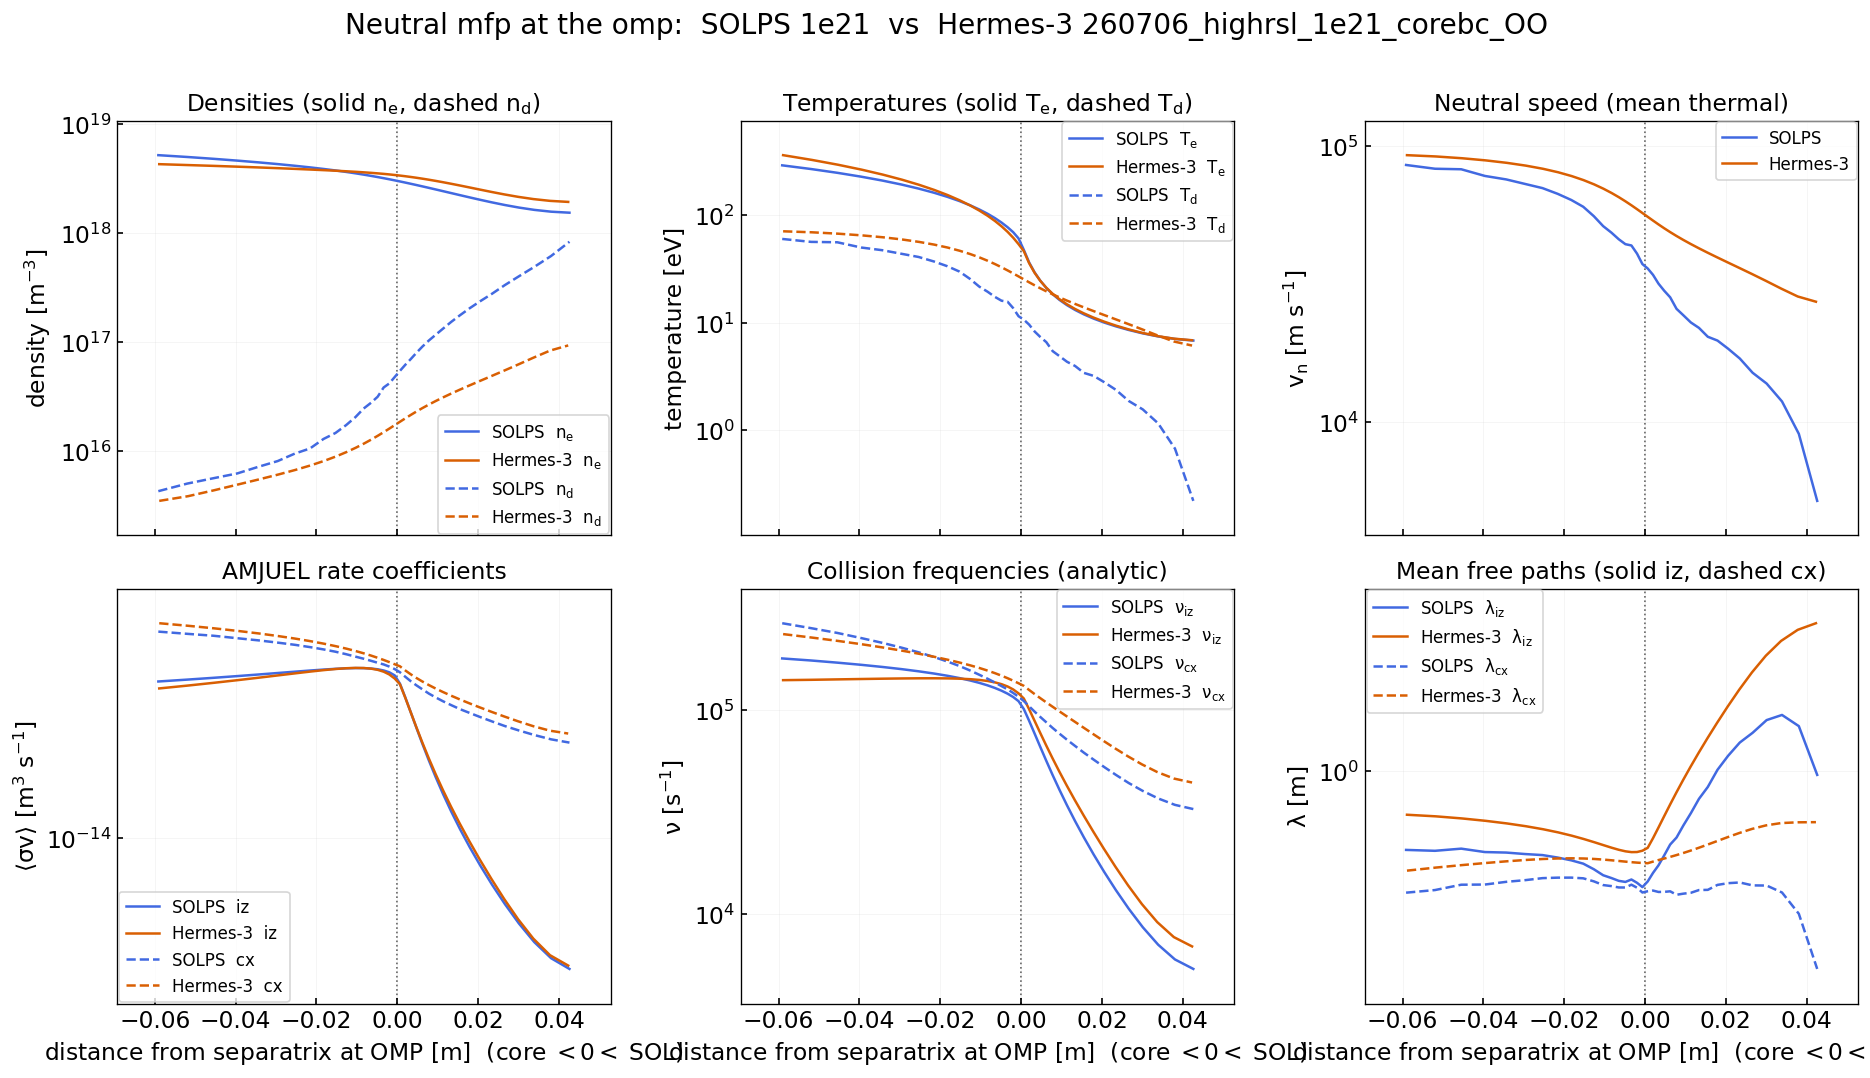

In [23]:
# ============================================================================
# Figure 1: what sets the mfp (profiles) and the mfp itself.
# ============================================================================

setup_matplotlib()
fig, axs = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
axs = axs.flatten()

def _sep(ax):
    ax.axvline(0.0, color="0.35", lw=1.0, ls=":", zorder=0)
    ax.grid(alpha=0.25)

# (1) densities -----------------------------------------------------------------
ax = axs[0]
ax.plot(df_s["srad"], df_s["Ne"], color=C_SOLPS,  ls=LS_IZ, label="SOLPS  $n_e$")
ax.plot(df_h["srad"], df_h["Ne"], color=C_HERMES, ls=LS_IZ, label="Hermes-3  $n_e$")
ax.plot(df_s["srad"], df_s["Nd"], color=C_SOLPS,  ls=LS_CX, label="SOLPS  $n_d$")
ax.plot(df_h["srad"], df_h["Nd"], color=C_HERMES, ls=LS_CX, label="Hermes-3  $n_d$")
ax.set_yscale("log"); ax.set_ylabel("density [m$^{-3}$]")
ax.set_title("Densities (solid $n_e$, dashed $n_d$)")
ax.legend(fontsize=10); _sep(ax)

# (2) temperatures ---------------------------------------------------------------
ax = axs[1]
ax.plot(df_s["srad"], df_s["Te"], color=C_SOLPS,  ls=LS_IZ, label="SOLPS  $T_e$")
ax.plot(df_h["srad"], df_h["Te"], color=C_HERMES, ls=LS_IZ, label="Hermes-3  $T_e$")
ax.plot(df_s["srad"], df_s["Td"], color=C_SOLPS,  ls=LS_CX, label="SOLPS  $T_d$")
ax.plot(df_h["srad"], df_h["Td"], color=C_HERMES, ls=LS_CX, label="Hermes-3  $T_d$")
ax.set_yscale("log"); ax.set_ylabel("temperature [eV]")
ax.set_title("Temperatures (solid $T_e$, dashed $T_d$)")
ax.legend(fontsize=10); _sep(ax)

# (3) neutral speed ---------------------------------------------------------------
ax = axs[2]
ax.plot(df_s["srad"], df_s["vn"], color=C_SOLPS,  ls=LS_IZ, label="SOLPS")
ax.plot(df_h["srad"], df_h["vn"], color=C_HERMES, ls=LS_IZ, label="Hermes-3")
ax.set_yscale("log"); ax.set_ylabel("$v_n$ [m s$^{-1}$]")
ax.set_title(f"Neutral speed ({SPEED_KIND} thermal)")
ax.legend(fontsize=10); _sep(ax)

# (4) rate coefficients ------------------------------------------------------------
ax = axs[3]
ax.plot(df_s["srad"], df_s["sigmav_iz"], color=C_SOLPS,  ls=LS_IZ, label="SOLPS  iz")
ax.plot(df_h["srad"], df_h["sigmav_iz"], color=C_HERMES, ls=LS_IZ, label="Hermes-3  iz")
ax.plot(df_s["srad"], df_s["sigmav_cx"], color=C_SOLPS,  ls=LS_CX, label="SOLPS  cx")
ax.plot(df_h["srad"], df_h["sigmav_cx"], color=C_HERMES, ls=LS_CX, label="Hermes-3  cx")
ax.set_yscale("log"); ax.set_ylabel(r"$\langle\sigma v\rangle$ [m$^3$ s$^{-1}$]")
ax.set_title("AMJUEL rate coefficients")
ax.legend(fontsize=10); _sep(ax)

# (5) collision frequencies ---------------------------------------------------------
ax = axs[4]
ax.plot(df_s["srad"], df_s["nu_iz"], color=C_SOLPS,  ls=LS_IZ, label=r"SOLPS  $\nu_{iz}$")
ax.plot(df_h["srad"], df_h["nu_iz"], color=C_HERMES, ls=LS_IZ, label=r"Hermes-3  $\nu_{iz}$")
ax.plot(df_s["srad"], df_s["nu_cx"], color=C_SOLPS,  ls=LS_CX, label=r"SOLPS  $\nu_{cx}$")
ax.plot(df_h["srad"], df_h["nu_cx"], color=C_HERMES, ls=LS_CX, label=r"Hermes-3  $\nu_{cx}$")
ax.set_yscale("log"); ax.set_ylabel(r"$\nu$ [s$^{-1}$]")
ax.set_title("Collision frequencies (analytic)")
ax.legend(fontsize=10); _sep(ax)

# (6) mean free paths ----------------------------------------------------------------
ax = axs[5]
ax.plot(df_s["srad"], df_s["lambda_iz"], color=C_SOLPS,  ls=LS_IZ, label=r"SOLPS  $\lambda_{iz}$")
ax.plot(df_h["srad"], df_h["lambda_iz"], color=C_HERMES, ls=LS_IZ, label=r"Hermes-3  $\lambda_{iz}$")
ax.plot(df_s["srad"], df_s["lambda_cx"], color=C_SOLPS,  ls=LS_CX, label=r"SOLPS  $\lambda_{cx}$")
ax.plot(df_h["srad"], df_h["lambda_cx"], color=C_HERMES, ls=LS_CX, label=r"Hermes-3  $\lambda_{cx}$")
ax.set_yscale("log"); ax.set_ylabel(r"$\lambda$ [m]")
ax.set_title("Mean free paths (solid iz, dashed cx)")
ax.legend(fontsize=10); _sep(ax)

for ax in axs[3:]:
    ax.set_xlabel("distance from separatrix at OMP [m]  (core $<0<$ SOL)")

fig.suptitle(f"Neutral mfp at the {REGION}:  SOLPS {SOLPS_KEY}  vs  Hermes-3 {HERMES_KEY}", y=1.0)
fig.tight_layout()
plt.show()


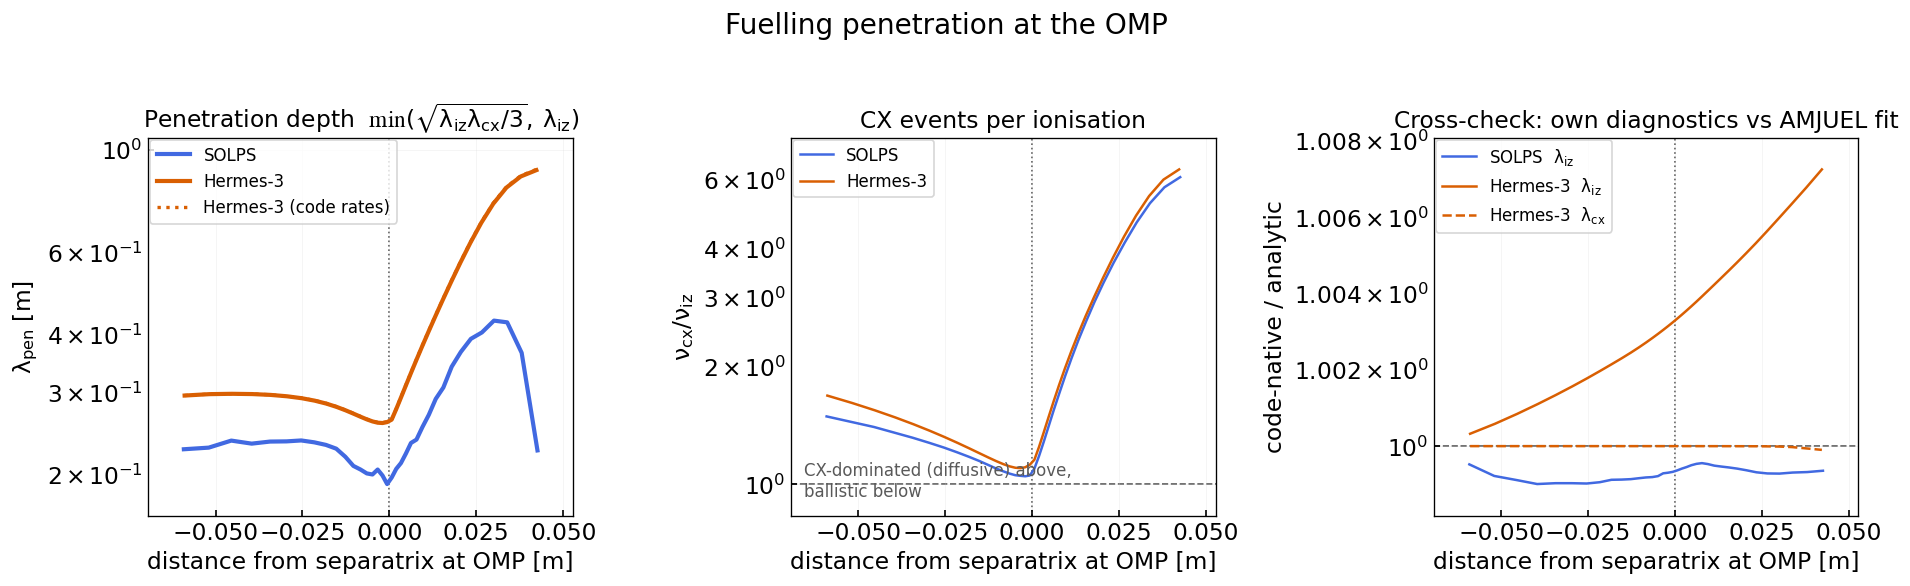

In [24]:
# ============================================================================
# Figure 2: penetration depth, regime, and analytic-vs-code-native cross-check.
# ============================================================================

fig, axs = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True)

def _sep(ax):
    ax.axvline(0.0, color="0.35", lw=1.0, ls=":", zorder=0)
    ax.grid(alpha=0.25)
    ax.set_xlabel("distance from separatrix at OMP [m]")

# (1) penetration depth -------------------------------------------------------------
ax = axs[0]
ax.plot(df_s["srad"], df_s["lambda_pen_eff"], color=C_SOLPS,  ls=LS_IZ, lw=2.5, label="SOLPS")
ax.plot(df_h["srad"], df_h["lambda_pen_eff"], color=C_HERMES, ls=LS_IZ, lw=2.5, label="Hermes-3")
if "lambda_pen_code" in df_h:
    ax.plot(df_h["srad"], df_h["lambda_pen_code"], color=C_HERMES, ls=":", lw=2.0,
            label="Hermes-3 (code rates)")
ax.set_yscale("log"); ax.set_ylabel(r"$\lambda_{pen}$ [m]")
ax.set_title(r"Penetration depth  $\min(\sqrt{\lambda_{iz}\lambda_{cx}/3},\ \lambda_{iz})$")
ax.legend(fontsize=10); _sep(ax)

# (2) regime: how many CX per ionisation --------------------------------------------
ax = axs[1]
ax.plot(df_s["srad"], df_s["nu_cx"] / df_s["nu_iz"], color=C_SOLPS,  ls=LS_IZ, label="SOLPS")
ax.plot(df_h["srad"], df_h["nu_cx"] / df_h["nu_iz"], color=C_HERMES, ls=LS_IZ, label="Hermes-3")
ax.axhline(1.0, color="0.35", lw=1.0, ls="--", zorder=0)
ax.annotate("CX-dominated (diffusive) above,\nballistic below", xy=(0.03, 0.05),
            xycoords="axes fraction", fontsize=10, color="0.35")
ax.set_yscale("log"); ax.set_ylabel(r"$\nu_{cx}/\nu_{iz}$")
ax.set_title("CX events per ionisation")
ax.legend(fontsize=10); _sep(ax)

# (3) analytic vs code-native ---------------------------------------------------------
ax = axs[2]
if "lambda_iz_code" in df_s:
    ax.plot(df_s["srad"], df_s["lambda_iz_code"] / df_s["lambda_iz"], color=C_SOLPS,
            ls=LS_IZ, label=r"SOLPS  $\lambda_{iz}$")
if "lambda_iz_code" in df_h:
    ax.plot(df_h["srad"], df_h["lambda_iz_code"] / df_h["lambda_iz"], color=C_HERMES,
            ls=LS_IZ, label=r"Hermes-3  $\lambda_{iz}$")
if "lambda_cx_code" in df_h:
    ax.plot(df_h["srad"], df_h["lambda_cx_code"] / df_h["lambda_cx"], color=C_HERMES,
            ls=LS_CX, label=r"Hermes-3  $\lambda_{cx}$")
ax.axhline(1.0, color="0.35", lw=1.0, ls="--", zorder=0)
ax.set_yscale("log"); ax.set_ylabel("code-native / analytic")
ax.set_title("Cross-check: own diagnostics vs AMJUEL fit")
ax.legend(fontsize=10); _sep(ax)

fig.suptitle("Fuelling penetration at the OMP", y=1.02)
fig.tight_layout()
plt.show()


### How to read the result

- **Panel 6 / Figure 2 left** is the answer to "how deep does the fuelling get".
  If $\lambda_{pen}^{SOLPS} > \lambda_{pen}^{Hermes}$, SOLPS neutrals reach further
  inside the separatrix and its ionisation source sits deeper in the core.
- **Figure 2 middle** tells you *why*. Where $\nu_{cx}/\nu_{iz}\gg 1$ the neutral takes
  many CX steps before it is ionised, so transport is a random walk and
  $\lambda_{pen}=\sqrt{\lambda_{iz}\lambda_{cx}/3}$ applies — this is exactly the regime a
  fluid neutral model is *supposed* to reproduce. Where the ratio drops below 1 the
  neutrals are ballistic and the fluid model has no equivalent: EIRENE lets a fast atom
  fly straight through, whereas Hermes-3's diffusive `Dnn` closure cannot.
- **Figure 2 right** isolates model choices from physics. A flat line at 1 means the
  analytic fit reproduces the code's own rate. A Hermes-3 CX ratio pinned at 100 is the
  `rate_multiplier` in `BOUT.inp`; a SOLPS ionisation ratio away from 1 is the kinetic
  correction EIRENE applies on top of the Maxwellian-averaged fit (non-Maxwellian atom
  distribution, molecular channels, opacity).

### Next steps if the mfp comparison is not conclusive

1. Compare `Sd+_iz` directly, and its radial cumulative integral
   $\int S_{iz}\,\mathrm{d}V$ from the wall inwards — the depth at which 50 % of the
   ionisation has happened is the operational "penetration depth" and does not depend on
   any mfp formula.
2. Repeat the mfp block with `SPEED_KIND="rms"` and with a fixed 3 eV Franck-Condon atom
   to bracket the EIRENE non-Maxwellian effect.
3. Run the same block on the `cx100_1e21` SOLPS case and the Hermes-3 `cx100` runs to see
   whether an enhanced CX brings the fluid penetration depth onto the kinetic one.
